# Day-Ahead-Arbitrage: 2h-Batteriespeicher (10 MW / 20 MWh)

**Betreiber-Annahme:** Vermarktung am EPEX-Spot Day-Ahead-Markt (Deutschland/Luxemburg).

**Modell:** Lineares gemischt-ganzzahliges Optimierungsproblem (MILP) in Pyomo, gelöst mit HiGHS.

| Parameter | Wert |
|---|---|
| max. Leistung $P^{\max}$ | 10 MW |
| Kapazität $E^{\max}$ | 20 MWh (2 h) |
| Round-Trip-Wirkungsgrad $\eta_{rt}$ | 90 % (symmetrisch: $\eta_c=\eta_d=\sqrt{0.9}$) |
| Zeitauflösung $\Delta t$ | 15 min, Horizont 24 h |

**Zielfunktion**

$$\max \sum_t \pi_t\,(p^{d}_t - p^{c}_t)\,\Delta t$$

**SoC-Bilanz & Grenzen**

$$SoC_t = SoC_{t-1} + \Big(\eta_c\,p^{c}_t - \tfrac{1}{\eta_d}\,p^{d}_t\Big)\Delta t, \qquad 0\le SoC_t\le E^{\max}, \qquad SoC_T = SoC_0$$

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

In [2]:
# ===== Speicher-Parameter =====
P_MAX  = 10.0      # max. Lade-/Entladeleistung [MW]
E_MAX  = 20.0      # nutzbare Kapazität [MWh]  -> 2h-Speicher
ETA_RT = 0.90      # Round-Trip-Wirkungsgrad
ETA_C  = ETA_RT ** 0.5   # Ladewirkungsgrad   (symmetrische Aufteilung)
ETA_D  = ETA_RT ** 0.5   # Entladewirkungsgrad
DT     = 0.25       # Zeitschrittdauer [h]
SOC0   = 0.0       # Anfangsfuellstand [MWh]
SOC_MIN, SOC_MAX = 0.0, E_MAX
DAY = "2026-06-18"

print(f"eta_c = eta_d = {ETA_C:.4f}  ->  Round-Trip = {ETA_C*ETA_D:.2%}")

eta_c = eta_d = 0.9487  ->  Round-Trip = 90.00%


In [3]:
# ===== Day-Ahead-Preise [EUR/MWh] =====

def fetch_dayahead_energy_charts(country="DE-LU", day=DAY):
    # echte Day-Ahead-Preise von der offenen energy-charts.info API
    import requests
    url = "https://api.energy-charts.info/price"
    r = requests.get(url, params={"bzn": country.upper(),
                                  "start": day, "end": day}, timeout=30)
    r.raise_for_status()
    data = r.json()
    return data["price"]

prices = fetch_dayahead_energy_charts(country="DE-LU", day="2026-06-18")

T = len(prices)
print(f"{T} Viertelstunden | Preis:  min = {min(prices)}  max = {max(prices)}  Spread = {max(prices)-min(prices)} EUR/MWh")

/Users/henningpaul/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


96 Viertelstunden | Preis:  min = 11.01  max = 544.75  Spread = 533.74 EUR/MWh


In [4]:
# ===== Optimierungsmodell (Pyomo / MILP) =====
def build_model(prices):
    m = pyo.ConcreteModel("BatteryArbitrage")
    m.T = pyo.RangeSet(0, len(prices) - 1)

    # Entscheidungsvariablen
    m.pc  = pyo.Var(m.T, domain=pyo.NonNegativeReals, bounds=(0, P_MAX))  # Laden [MW]
    m.pd  = pyo.Var(m.T, domain=pyo.NonNegativeReals, bounds=(0, P_MAX))  # Entladen [MW]
    m.soc = pyo.Var(m.T, domain=pyo.NonNegativeReals, bounds=(SOC_MIN, SOC_MAX))  # [MWh]
    m.u   = pyo.Var(m.T, domain=pyo.Binary)   # 1 = Lademodus (verhindert gleichzeitig laden+entladen)

    # Zielfunktion: Erloesmaximierung am AC-Netzanschluss
    m.obj = pyo.Objective(expr=sum(prices[t] * (m.pd[t] - m.pc[t]) * DT for t in m.T), sense=pyo.maximize)

    # SoC-Bilanz: Ladeverlust ueber eta_c, Entladeverlust ueber 1/eta_d
    def soc_balance(m, t):
        prev = SOC0 if t == 0 else m.soc[t - 1]
        return m.soc[t] == prev + (ETA_C * m.pc[t] - (1.0 / ETA_D) * m.pd[t]) * DT
    m.soc_balance = pyo.Constraint(m.T, rule=soc_balance)

    # Lade-/Entlade-Exklusivitaet
    m.charge_lim    = pyo.Constraint(m.T, rule=lambda m, t: m.pc[t] <= P_MAX * m.u[t])
    m.discharge_lim = pyo.Constraint(m.T, rule=lambda m, t: m.pd[t] <= P_MAX * (1 - m.u[t]))

    # End-SoC = Anfangs-SoC (kein kuenstlicher Enderloes durch Leerraeumen)
    m.end_soc = pyo.Constraint(expr=m.soc[len(prices) - 1] == SOC0)
    return m

model = build_model(prices)
result = pyo.SolverFactory("appsi_highs").solve(model)
print("Status:", result.solver.termination_condition)
print(f"Tageserlös: {pyo.value(model.obj):,.2f} EUR")

Status: optimal
Tageserlös: 8,624.47 EUR


In [5]:
# ===== Ergebnisse aufbereiten =====
df = pd.DataFrame({
    "Viertelstunde":    list(model.T),
    "Preis":            prices,
    "Laden_MW":         [round(pyo.value(model.pc[t]), 3) for t in model.T],
    "Entladen_MW":      [round(pyo.value(model.pd[t]), 3) for t in model.T],
    "SoC_MWh":          [round(pyo.value(model.soc[t]), 3) for t in model.T],
})
df["Netto_MW"]    = df["Entladen_MW"] - df["Laden_MW"]
df["Cashflow_EUR"] = df["Preis"] * df["Netto_MW"] * DT

# Kennzahlen
energie_geladen   = df["Laden_MW"].sum() * DT          # MWh (AC)
energie_entladen  = df["Entladen_MW"].sum() * DT       # MWh (AC)
vollzyklen        = energie_entladen / E_MAX
summary = {
    "Tageserlös [EUR]":       round(df["Cashflow_EUR"].sum(), 2),
    "Energie geladen [MWh]":  round(energie_geladen, 2),
    "Energie entladen [MWh]": round(energie_entladen, 2),
    "Äquiv. Vollzyklen":     round(vollzyklen, 2),
    "\u2205-Preis Laden [EUR/MWh]":   round((df.loc[df.Laden_MW>0,"Preis"]*df.loc[df.Laden_MW>0,"Laden_MW"]*DT).sum()/max(energie_geladen,1e-9),1),
    "\u2205-Preis Entladen [EUR/MWh]":round((df.loc[df.Entladen_MW>0,"Preis"]*df.loc[df.Entladen_MW>0,"Entladen_MW"]*DT).sum()/max(energie_entladen,1e-9),1),
}
for k, v in summary.items():
    print(f"{k:30s}: {v}")

Tageserlös [EUR]              : 8624.51
Energie geladen [MWh]         : 62.5
Energie entladen [MWh]        : 56.25
Äquiv. Vollzyklen             : 2.81
∅-Preis Laden [EUR/MWh]       : 74.7
∅-Preis Entladen [EUR/MWh]    : 236.3


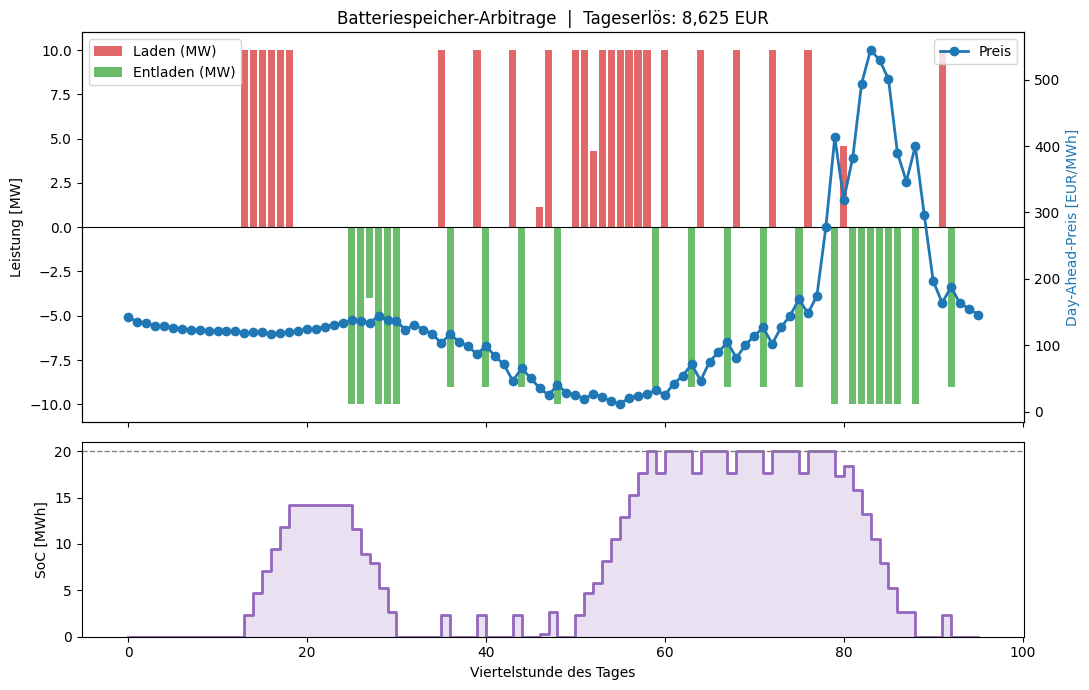

In [6]:
# ===== Visualisierung: Preis, Leistung, SoC =====
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# oben: Preis + Lade-/Entladeleistung
ax1.bar(df.Viertelstunde, df.Laden_MW,   width=0.8, color="#d62728", alpha=0.7, label="Laden (MW)")
ax1.bar(df.Viertelstunde, -df.Entladen_MW, width=0.8, color="#2ca02c", alpha=0.7, label="Entladen (MW)")
ax1.set_ylabel("Leistung [MW]")
ax1.axhline(0, color="k", lw=0.8)
axp = ax1.twinx()
axp.plot(df.Viertelstunde, df.Preis, "o-", color="#1f77b4", lw=2, label="Preis")
axp.set_ylabel("Day-Ahead-Preis [EUR/MWh]", color="#1f77b4")
ax1.legend(loc="upper left"); axp.legend(loc="upper right")
ax1.set_title(f"Batteriespeicher-Arbitrage  |  Tageserlös: {df.Cashflow_EUR.sum():,.0f} EUR")

# unten: SoC-Verlauf
ax2.step(df.Viertelstunde, df.SoC_MWh, where="post", color="#9467bd", lw=2)
ax2.fill_between(df.Viertelstunde, df.SoC_MWh, step="post", alpha=0.2, color="#9467bd")
ax2.axhline(E_MAX, ls="--", color="gray", lw=1)
ax2.set_ylabel("SoC [MWh]"); ax2.set_xlabel("Viertelstunde des Tages")
ax2.set_ylim(0, E_MAX * 1.05)
plt.tight_layout()
plt.show()